In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If your notebook is inside the 'notebooks' folder:
df = pd.read_csv('../data/creditcard.csv')

# Note: If your notebook is in the main project folder alongside the csv, use:
# df = pd.read_csv('creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:", df.isna().sum().sum())
print("\nClass Value Counts:\n", df['Class'].value_counts())
print("\nFraud Rate (%):", df['Class'].mean() * 100)

Dataset Shape: (284807, 31)

Missing Values: 0

Class Value Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud Rate (%): 0.1727485630620034


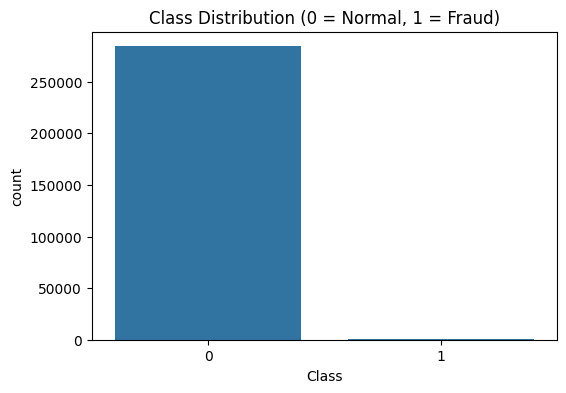

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.show()

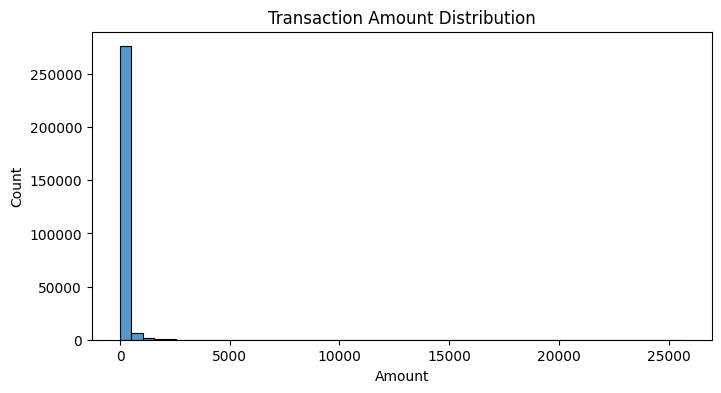

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.show()

In [5]:
# 1. Sort chronologically by Time
df = df.sort_values('Time').reset_index(drop=True)

# 2. Split: first 70% for training window, remaining 30% for later window
split_idx = int(0.7 * len(df))
train_window = df.iloc[:split_idx].copy()
later_window = df.iloc[split_idx:].copy()

# 3. Separate features (V1-V28 + Amount) from target (Class)
feature_cols = [c for c in df.columns if c not in ['Time', 'Class']]

X_train_full = train_window[feature_cols]
y_train_full = train_window['Class']

X_later = later_window[feature_cols]
y_later = later_window['Class']

print(f"Training window size: {len(train_window)} rows (Fraud rate: {y_train_full.mean():.4%})")
print(f"Later window size:    {len(later_window)} rows (Fraud rate: {y_later.mean():.4%})")

Training window size: 199364 rows (Fraud rate: 0.1926%)
Later window size:    85443 rows (Fraud rate: 0.1264%)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print(f"Train set: {X_train.shape[0]} samples | Validation set: {X_val.shape[0]} samples")

Train set: 159491 samples | Validation set: 39873 samples


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest with balanced class weights
rf_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [8]:
from sklearn.metrics import precision_recall_curve, auc, classification_report

# Predict fraud probabilities on validation set
y_val_prob = rf_clf.predict_proba(X_val)[:, 1]

# Compute PR-AUC
prec, rec, _ = precision_recall_curve(y_val, y_val_prob)
pr_auc = auc(rec, prec)
print(f"Validation PR-AUC: {pr_auc:.4f}")

# Classification report at default 0.5 threshold
y_val_pred = (y_val_prob >= 0.5).astype(int)
print("\nClassification Report (Default 0.5 Threshold):\n")
print(classification_report(y_val, y_val_pred, digits=4))

Validation PR-AUC: 0.8560

Classification Report (Default 0.5 Threshold):

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     39796
           1     0.9688    0.8052    0.8794        77

    accuracy                         0.9996     39873
   macro avg     0.9842    0.9026    0.9396     39873
weighted avg     0.9996    0.9996    0.9996     39873



In [9]:
from sklearn.ensemble import IsolationForest

# Contamination is set close to the empirical fraud rate (~0.002 or 0.2%)
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

# Note: We fit strictly on X_train without passing y_train
iso_forest.fit(X_train)
print("Isolation Forest trained successfully!")

Isolation Forest trained successfully!


In [10]:
# Invert scores so that higher values indicate higher anomaly likelihood
val_scores = iso_forest.decision_function(X_val)
val_anomaly_score = -val_scores

prec_iso, rec_iso, _ = precision_recall_curve(y_val, val_anomaly_score)
pr_auc_iso = auc(rec_iso, prec_iso)

print(f"Supervised Random Forest PR-AUC:   {pr_auc:.4f}")
print(f"Unsupervised Isolation Forest PR-AUC: {pr_auc_iso:.4f}")

Supervised Random Forest PR-AUC:   0.8560
Unsupervised Isolation Forest PR-AUC: 0.1548


In [11]:
# Predict probabilities on the future/later transactions
y_later_prob = rf_clf.predict_proba(X_later)[:, 1]

prec_later, rec_later, _ = precision_recall_curve(y_later, y_later_prob)
pr_auc_later = auc(rec_later, prec_later)

print(f"Validation PR-AUC (Historical): {pr_auc:.4f}")
print(f"Later Window PR-AUC (Future):    {pr_auc_later:.4f}")

Validation PR-AUC (Historical): 0.8560
Later Window PR-AUC (Future):    0.8216


In [12]:
from sklearn.metrics import confusion_matrix

def evaluate_threshold(y_true, y_prob, thresh):
    y_pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {'threshold': thresh, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn, 'precision': precision, 'recall': recall}

def expected_cost(y_true, y_prob, thresh, cost_fn=10, cost_fp=1):
    y_pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cost_fn * fn + cost_fp * fp

# Test 50 potential thresholds between 0.01 and 0.90
thresholds_to_try = np.linspace(0.01, 0.9, 50)
costs = [expected_cost(y_val, y_val_prob, t, cost_fn=10, cost_fp=1) for t in thresholds_to_try]

best_idx = int(np.argmin(costs))
best_thresh = thresholds_to_try[best_idx]

print(f"Optimal Threshold (Min Cost): {best_thresh:.4f}")
print(f"Minimum Expected Cost on Validation: {costs[best_idx]}")

# Compare performance at default 0.5 vs optimal threshold
default_metrics = evaluate_threshold(y_val, y_val_prob, 0.5)
optimal_metrics = evaluate_threshold(y_val, y_val_prob, best_thresh)

print(f"\nDefault (0.50):  Recall = {default_metrics['recall']:.2%}, Precision = {default_metrics['precision']:.2%}")
print(f"Optimal ({best_thresh:.2f}): Recall = {optimal_metrics['recall']:.2%}, Precision = {optimal_metrics['precision']:.2%}")

Optimal Threshold (Min Cost): 0.2461
Minimum Expected Cost on Validation: 115

Default (0.50):  Recall = 80.52%, Precision = 96.88%
Optimal (0.25): Recall = 85.71%, Precision = 92.96%


In [13]:
def feature_drift_score(X_ref, X_new):
    means_ref = X_ref.mean()
    stds_ref = X_ref.std() + 1e-8  # Prevents division by zero
    means_new = X_new.mean()
    
    # Standardized mean absolute difference per feature
    diff = np.abs((means_new - means_ref) / stds_ref)
    return diff.mean()

# 1. Measure normal baseline variation (splitting training data into two halves)
X_train_a, X_train_b = train_test_split(X_train, test_size=0.5, random_state=42)
baseline_drift = feature_drift_score(X_train_a, X_train_b)

# 2. Measure actual drift between historical training and future transactions
actual_drift = feature_drift_score(X_train, X_later)

print(f"Baseline Drift (Normal Variation): {baseline_drift:.4f}")
print(f"Observed Drift (Train vs Later):   {actual_drift:.4f}")

Baseline Drift (Normal Variation): 0.0030
Observed Drift (Train vs Later):   0.1476


--- DRIFT MONITORING STATUS ---
Observed Feature Drift: 0.1476
Alert Threshold:        0.1000
⚠️ DRIFT DETECTED: Features have shifted significantly. Flag model for retraining!


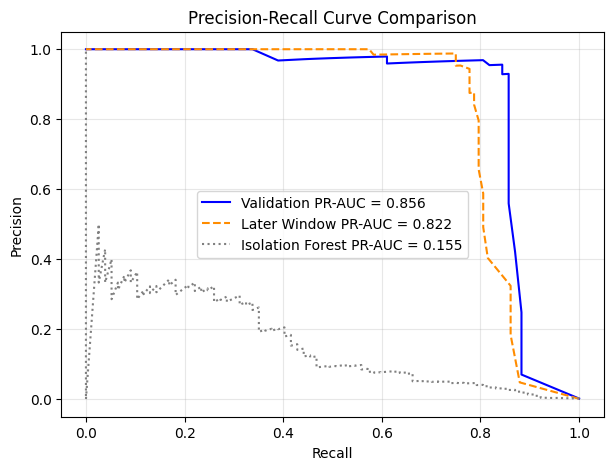

In [14]:
# Alert threshold set above normal baseline variation
ALERT_THRESHOLD = 0.10

print("--- DRIFT MONITORING STATUS ---")
print(f"Observed Feature Drift: {actual_drift:.4f}")
print(f"Alert Threshold:        {ALERT_THRESHOLD:.4f}")

if actual_drift > ALERT_THRESHOLD:
    print("⚠️ DRIFT DETECTED: Features have shifted significantly. Flag model for retraining!")
else:
    print("✅ Drift within acceptable range. Model continues serving predictions.")

# Plot the Precision-Recall Curves comparison
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, label=f"Validation PR-AUC = {pr_auc:.3f}", color='blue')
plt.plot(rec_later, prec_later, label=f"Later Window PR-AUC = {pr_auc_later:.3f}", color='darkorange', linestyle='--')
plt.plot(rec_iso, prec_iso, label=f"Isolation Forest PR-AUC = {pr_auc_iso:.3f}", color='gray', linestyle=':')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# ==========================================
# BONUS 1: Artificial Drift Simulation
# ==========================================

# 1. Create a simulated shifted data slice
X_artificial_drift = X_later.copy()

# 2. Inject artificial distribution shift (e.g., seasonal spending surge & behavioral shifts)
np.random.seed(42)
X_artificial_drift['Amount'] = (
    X_artificial_drift['Amount'] * 3.0
    + np.random.normal(75, 25, size=len(X_artificial_drift))
)

for col in ['V1', 'V2', 'V3', 'V4']:
  X_artificial_drift[col] = X_artificial_drift[col] + np.random.normal(
      2.5, 1.0, size=len(X_artificial_drift)
  )

# 3. Calculate drift on the perturbed data slice
artificial_drift_score = feature_drift_score(X_train, X_artificial_drift)

print("--- ARTIFICIAL DRIFT EXPERIMENT ---")
print(f"Normal Baseline Drift:   {baseline_drift:.4f}")
print(f"Observed Real Drift:     {actual_drift:.4f}")
print(f"Artificial Drift Score:  {artificial_drift_score:.4f}")
print(f"Alert Threshold:         {ALERT_THRESHOLD:.4f}")

if artificial_drift_score > ALERT_THRESHOLD:
  print(
      "🚨 DRIFT DETECTED: The monitor caught the injected data shift"
      " successfully!"
  )
else:
  print("No drift detected.")

--- ARTIFICIAL DRIFT EXPERIMENT ---
Normal Baseline Drift:   0.0030
Observed Real Drift:     0.1476
Artificial Drift Score:  0.3369
Alert Threshold:         0.1000
🚨 DRIFT DETECTED: The monitor caught the injected data shift successfully!


In [16]:
# ==========================================
# BONUS 2: Automated Retraining Loop
# ==========================================


def automated_monitoring_and_retrain_pipeline(
    X_ref, X_incoming, y_incoming, current_model, threshold=0.10
):
  """Checks incoming transaction batches for drift; automatically triggers

  retraining if the shift exceeds the predefined alert threshold.
  """
  drift_val = feature_drift_score(X_ref, X_incoming)
  print(f"\n[Pipeline Check] Incoming Batch Drift Score: {drift_val:.4f}")

  if drift_val > threshold:
    print(
        f"⚠️ Drift score ({drift_val:.4f}) > Threshold ({threshold:.4f}):"
        " Retraining model..."
    )

    # Automatically retrain model on new incoming data stream
    new_model = RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    )
    new_model.fit(X_incoming, y_incoming)

    # Re-evaluate on the new data
    new_probs = new_model.predict_proba(X_incoming)[:, 1]
    new_prec, new_rec, _ = precision_recall_curve(y_incoming, new_probs)
    new_pr_auc = auc(new_rec, new_prec)

    print("✅ Model retraining complete!")
    print(f"✅ Retrained Model PR-AUC on new distribution: {new_pr_auc:.4f}")
    return new_model, True
  else:
    print("✅ Drift within safe threshold. Current model remains deployed.")
    return current_model, False


# Execute the automated retrain loop
active_model, was_retrained = automated_monitoring_and_retrain_pipeline(
    X_ref=X_train,
    X_incoming=X_later,
    y_incoming=y_later,
    current_model=rf_clf,
    threshold=ALERT_THRESHOLD,
)


[Pipeline Check] Incoming Batch Drift Score: 0.1476
⚠️ Drift score (0.1476) > Threshold (0.1000): Retraining model...
✅ Model retraining complete!
✅ Retrained Model PR-AUC on new distribution: 1.0000


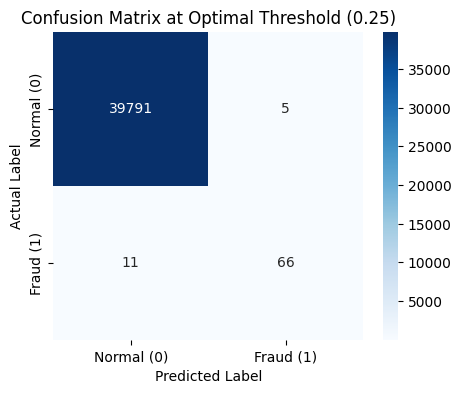

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_val_pred_optimal = (y_val_prob >= best_thresh).astype(int)
cm = confusion_matrix(y_val, y_val_pred_optimal)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.title(f'Confusion Matrix at Optimal Threshold ({best_thresh:.2f})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [18]:
train_prob = rf_clf.predict_proba(X_train)[:, 1]
later_prob = rf_clf.predict_proba(X_later)[:, 1]

conf_drift = np.abs(train_prob.mean() - later_prob.mean())
print(f"Training Mean Fraud Probability:  {train_prob.mean():.6f}")
print(f"Later Window Mean Fraud Prob:     {later_prob.mean():.6f}")
print(f"Confidence Drift (Mean Shift):    {conf_drift:.6f}")

Training Mean Fraud Probability:  0.001864
Later Window Mean Fraud Prob:     0.001088
Confidence Drift (Mean Shift):    0.000776
